In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [3]:
df = pd.read_csv("../data/atlantic_spain_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

lifecycle = pd.read_csv(
    "../data/lifecycle_advanced_features.csv",
    index_col=0
)

lifecycle.head()

,song_id,entry_date,exit_date,days_on_playlist,best_rank,worst_rank,avg_rank,initial_rank,rank_improvement,rank_range,rank_volatility,avg_daily_rank_change,peak_popularity,avg_popularity,popularity_gap,playlist_entries,days_to_peak,stability_score
0,0 confianza_rvfv,2025-06-02,2025-06-23,22,23,42,29.650000,40,17,19,5.659412,2.210526,62,57.550000,4.450000,20,5,3.303595
1,"1 de enero, puntacana_rels b",2025-04-28,2025-04-28,1,45,45,45.000000,45,0,0,0.000000,NaN,65,65.000000,0.000000,1,0,1.000000
2,1000cosas_lola indigo & manuel turizo,2025-03-10,2025-11-13,249,3,44,20.428571,3,0,41,9.585679,1.102459,81,76.171429,4.828571,245,0,23.522345
3,100xciento_foreign teck & eladio carrion & de ...,2025-04-30,2025-05-15,16,13,42,28.181818,42,29,29,9.086453,11.700000,75,73.727273,1.272727,11,11,1.586286
4,14 febreros_quevedo,2025-11-24,2025-11-27,4,9,16,13.500000,9,0,7,3.316625,2.333333,68,65.750000,2.250000,4,0,0.926650


In [4]:
print("Songs :", lifecycle.shape[0])
print("Features :", lifecycle.shape[1])

lifecycle.info()

lifecycle.describe()

Songs : 575
Features : 18
<class 'pandas.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   song_id                575 non-null    str    
 1   entry_date             575 non-null    str    
 2   exit_date              575 non-null    str    
 3   days_on_playlist       575 non-null    int64  
 4   best_rank              575 non-null    int64  
 5   worst_rank             575 non-null    int64  
 6   avg_rank               575 non-null    float64
 7   initial_rank           575 non-null    int64  
 8   rank_improvement       575 non-null    int64  
 9   rank_range             575 non-null    int64  
 10  rank_volatility        575 non-null    float64
 11  avg_daily_rank_change  492 non-null    float64
 12  peak_popularity        575 non-null    int64  
 13  avg_popularity         575 non-null    float64
 14  popularity_gap         575 non-null    floa

,days_on_playlist,best_rank,worst_rank,avg_rank,initial_rank,rank_improvement,rank_range,rank_volatility,avg_daily_rank_change,peak_popularity,avg_popularity,popularity_gap,playlist_entries,days_to_peak,stability_score
count,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,492.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000
mean,57.445217,21.793043,44.227826,32.125670,30.144348,8.351304,22.434783,7.223753,3.712123,74.264348,70.318486,3.945862,48.321739,9.485217,6.411530
std,89.966777,14.976775,9.644116,11.398608,15.789944,12.884980,16.158368,5.085133,3.767217,18.865368,19.082514,5.338267,73.866905,30.019205,11.958567
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.090037
25%,4.000000,9.000000,44.000000,24.288812,16.000000,0.000000,7.000000,2.911392,1.541233,69.000000,65.000000,1.000000,4.000000,0.000000,1.000000
50%,15.000000,20.000000,48.000000,33.930233,34.000000,0.000000,22.000000,7.211014,2.404545,78.000000,73.848739,2.750000,13.000000,0.000000,2.128265
75%,82.500000,35.000000,50.000000,41.159664,45.000000,13.000000,37.000000,11.195398,4.517857,85.000000,81.785247,4.459568,69.000000,7.500000,8.318155
max,551.000000,50.000000,50.000000,50.000000,50.000000,48.000000,49.000000,21.213203,30.000000,100.000000,99.962963,38.000000,539.000000,426.000000,198.048751


How long do songs survive?

In [5]:
print(lifecycle["days_on_playlist"].describe())

count    575.000000
mean      57.445217
std       89.966777
min        1.000000
25%        4.000000
50%       15.000000
75%       82.500000
max      551.000000
Name: days_on_playlist, dtype: float64


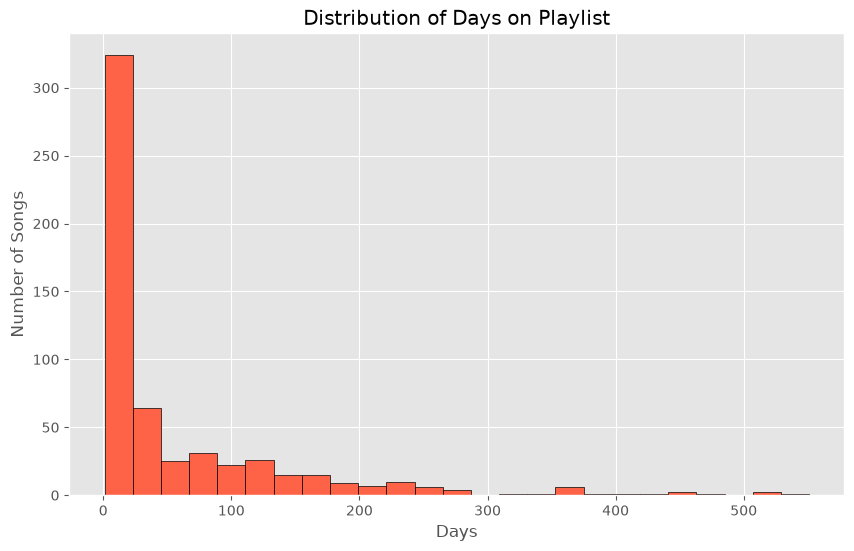

In [57]:
plt.figure(figsize=(10,6))

plt.hist(
    lifecycle["days_on_playlist"],
    bins=25,
    edgecolor="black",
    color="tomato"
)

plt.title("Distribution of Days on Playlist")
plt.xlabel("Days")
plt.ylabel("Number of Songs")

plt.show()

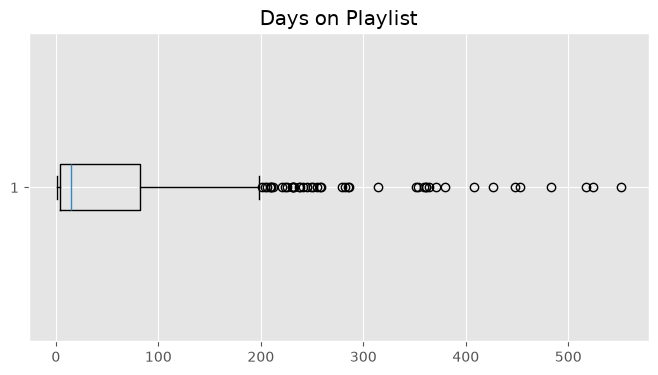

In [59]:
plt.figure(figsize=(8,4))

plt.boxplot(
    lifecycle["days_on_playlist"],
    orientation="horizontal"
)

plt.title("Days on Playlist")

plt.show()

Observation

The distribution of playlist survival is highly right-skewed. Most songs remain on the Spain Top 50 playlist for fewer than 50 days, while only a small number continue to appear for several hundred days.

Business Insight

This suggests that sustained playlist success is relatively rare. Atlantic Records should investigate the characteristics of these long-lasting songs to improve future release planning and promotional strategies.

Which songs survive the longest?

In [8]:
top10 = lifecycle.sort_values(
    "days_on_playlist",
    ascending=False
).head(10)

top10

,song_id,entry_date,exit_date,days_on_playlist,best_rank,worst_rank,avg_rank,initial_rank,rank_improvement,rank_range,rank_volatility,avg_daily_rank_change,peak_popularity,avg_popularity,popularity_gap,playlist_entries,days_to_peak,stability_score
265,la bachata_manuel turizo,2024-05-18,2025-11-19,551,11,50,26.786642,24,13,39,8.490150,1.929368,88,85.636364,2.363636,539,228,58.060199
29,amargura_karol g,2024-05-26,2025-10-31,524,16,50,32.764706,50,34,34,9.592188,1.953947,92,87.411765,4.588235,153,426,49.470423
546,vagabundo_sebastian yatra & manuel turizo & beéle,2024-05-18,2025-10-16,517,3,50,29.090674,39,36,47,16.005829,1.714286,91,85.264249,5.735751,386,17,30.401341
97,columbia_quevedo,2024-07-08,2025-11-02,483,1,50,19.584052,39,38,49,15.131870,1.315335,97,89.288793,7.711207,464,1,29.940733
293,lala_myke towers,2024-06-29,2025-09-24,453,1,50,20.000000,42,41,49,15.987495,1.293548,99,93.446945,5.553055,311,6,26.666674
524,tqg_karol g,2024-05-18,2025-08-08,448,9,50,31.983333,9,0,41,10.925249,1.689076,96,93.066667,2.933333,120,0,37.567350
429,qlona_karol g,2024-08-19,2025-10-19,427,8,50,26.472303,37,29,42,11.851356,1.891813,94,90.005831,3.994169,343,26,33.226066
26,amanece_anuel aa & haze,2024-05-25,2025-07-06,408,47,50,48.533333,50,3,3,1.060099,1.142857,85,81.466667,3.533333,15,29,198.048751
167,el merengue_marshmello,2024-11-04,2025-11-18,380,19,50,36.476341,20,1,31,7.413013,2.417722,81,77.791798,3.208202,317,1,45.168122
325,manos rotas_dellafuente & morad,2024-11-18,2025-11-23,371,1,50,23.595745,13,12,49,18.555720,1.301829,85,77.680851,7.319149,329,11,18.971432


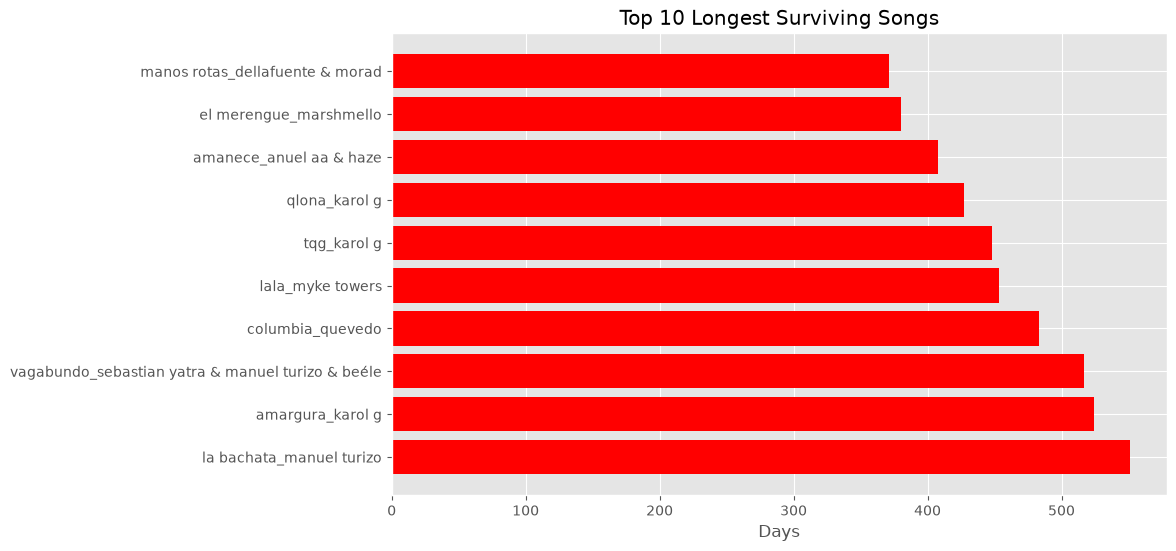

In [86]:
plt.figure(figsize=(10,6))

plt.barh(
    top10["song_id"],
    top10["days_on_playlist"],
    color="red"
)

plt.title("Top 10 Longest Surviving Songs")

plt.xlabel("Days")

plt.show()

Which artists dominate Spain?

In [10]:
artist_counts = (
    df.groupby("artist")["song_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(15)
)

artist_counts

artist
Myke Towers       24
Quevedo           24
Bad Bunny         22
Rauw Alejandro    19
Mora              19
Eladio Carrion    19
Feid              18
SAIKO             16
Duki              14
Rels B            10
Saiko              9
KAROL G            9
Cruz Cafuné        8
Aitana             6
Dei V              6
Name: song_id, dtype: int64

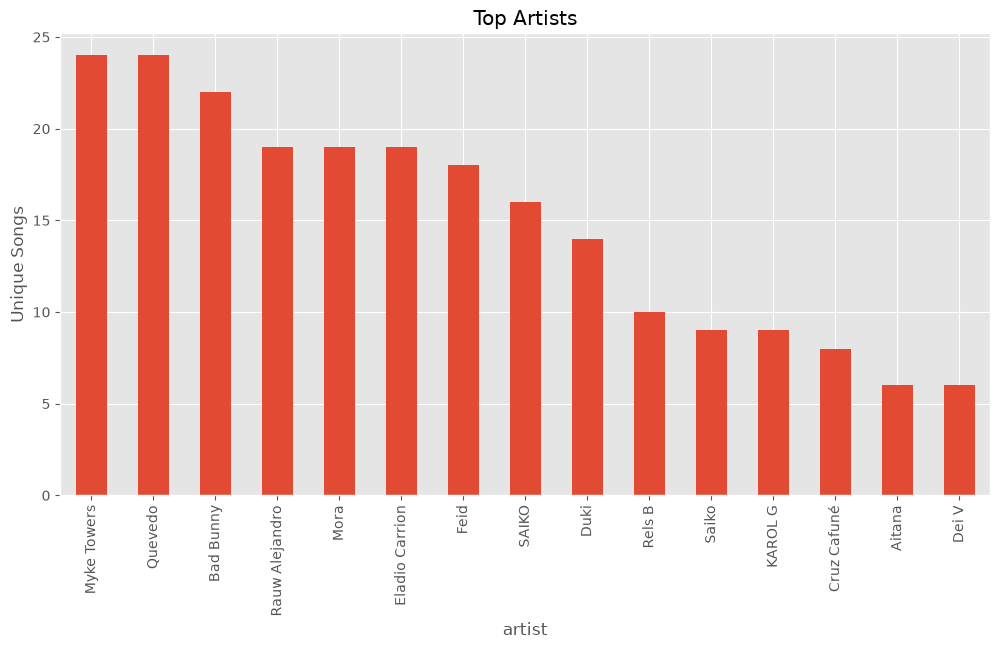

In [88]:
plt.figure(figsize=(12,6))

artist_counts.plot(kind="bar")

plt.title("Top Artists")

plt.ylabel("Unique Songs")

plt.show()

Single vs Album

In [12]:
album_type = (
    df.groupby("song_id")["album_type"]
      .first()
)

eda = lifecycle.merge(
    album_type,
    on="song_id"
)

In [13]:
eda.groupby("album_type")[
    [
        "days_on_playlist",
        "best_rank",
        "stability_score"
    ]
].mean()

,days_on_playlist,best_rank,stability_score
album_type,,,
album,48.332192,22.893836,5.578964
single,66.848057,20.657244,7.270574


<Axes: xlabel='album_type', ylabel='days_on_playlist'>

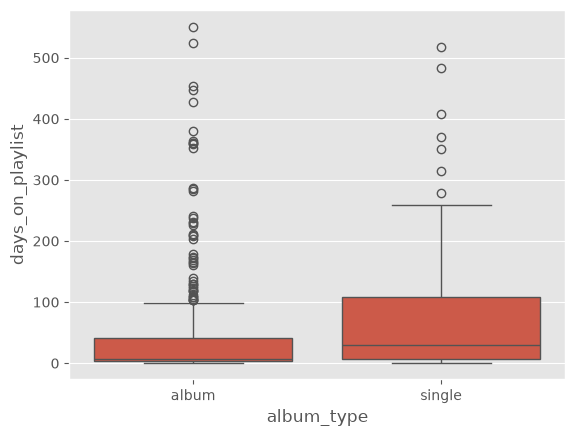

In [14]:
sns.boxplot(
    x="album_type",
    y="days_on_playlist",
    data=eda
)

Explicit vs Clean Songs

In [15]:
explicit = (
    df.groupby("song_id")["is_explicit"]
      .first()
)

eda = eda.merge(
    explicit,
    on="song_id"
)

In [16]:
eda.groupby("is_explicit")[
[
"days_on_playlist",
"best_rank",
"stability_score"
]
].mean()

,days_on_playlist,best_rank,stability_score
is_explicit,,,
False,59.876923,22.052308,7.117116
True,54.284000,21.456000,5.494269


<Axes: xlabel='is_explicit', ylabel='days_on_playlist'>

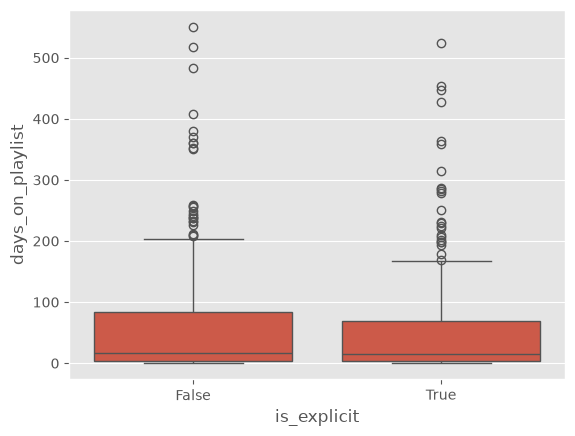

In [17]:
sns.boxplot(
x="is_explicit",
y="days_on_playlist",
data=eda
)

Rank Improvement

In [18]:
top15 = (
    lifecycle.sort_values(
        "rank_improvement",
        ascending=False
    )
    .head(15)
)

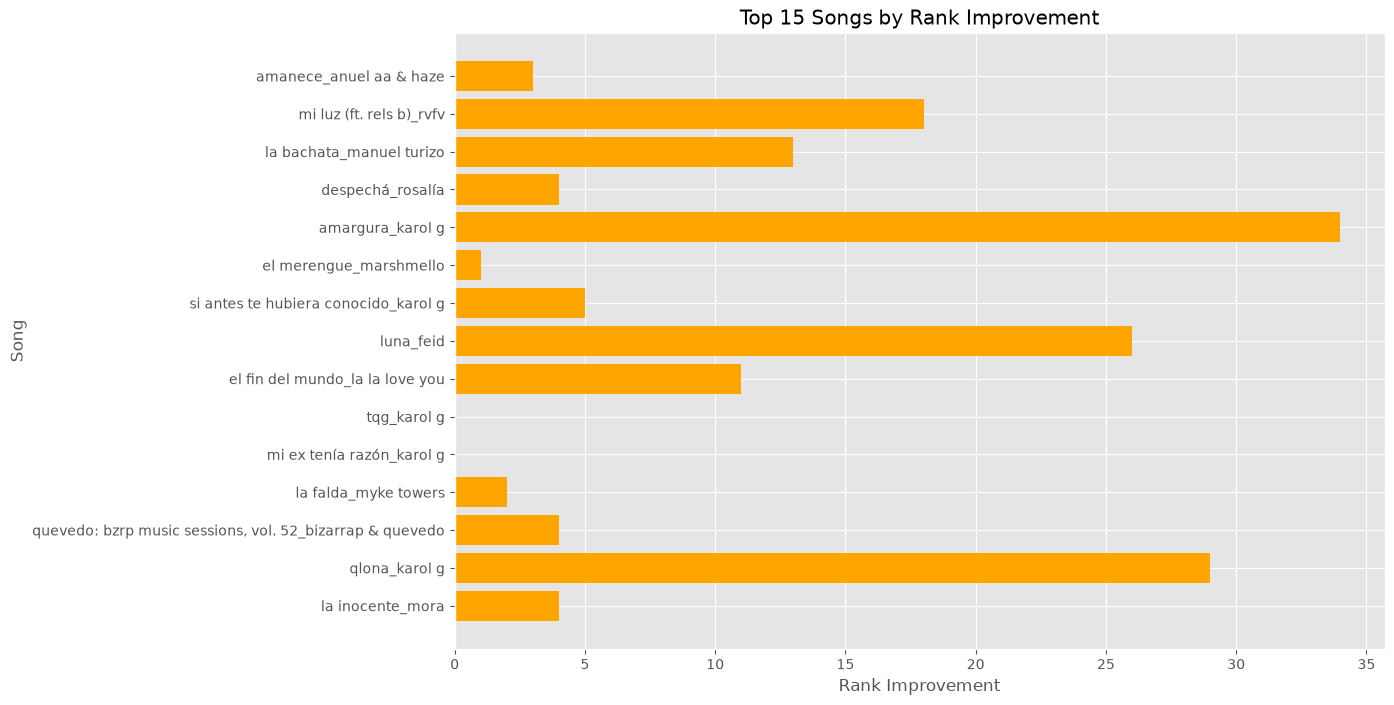

In [84]:
plt.figure(figsize=(12,8))

plt.barh(
    top15["song_id"],
    top15["rank_improvement"],
    color="orange"
)

plt.title("Top 15 Songs by Rank Improvement")
plt.xlabel("Rank Improvement")
plt.ylabel("Song")

plt.gca().invert_yaxis()   # Highest improvement at the top

plt.show()

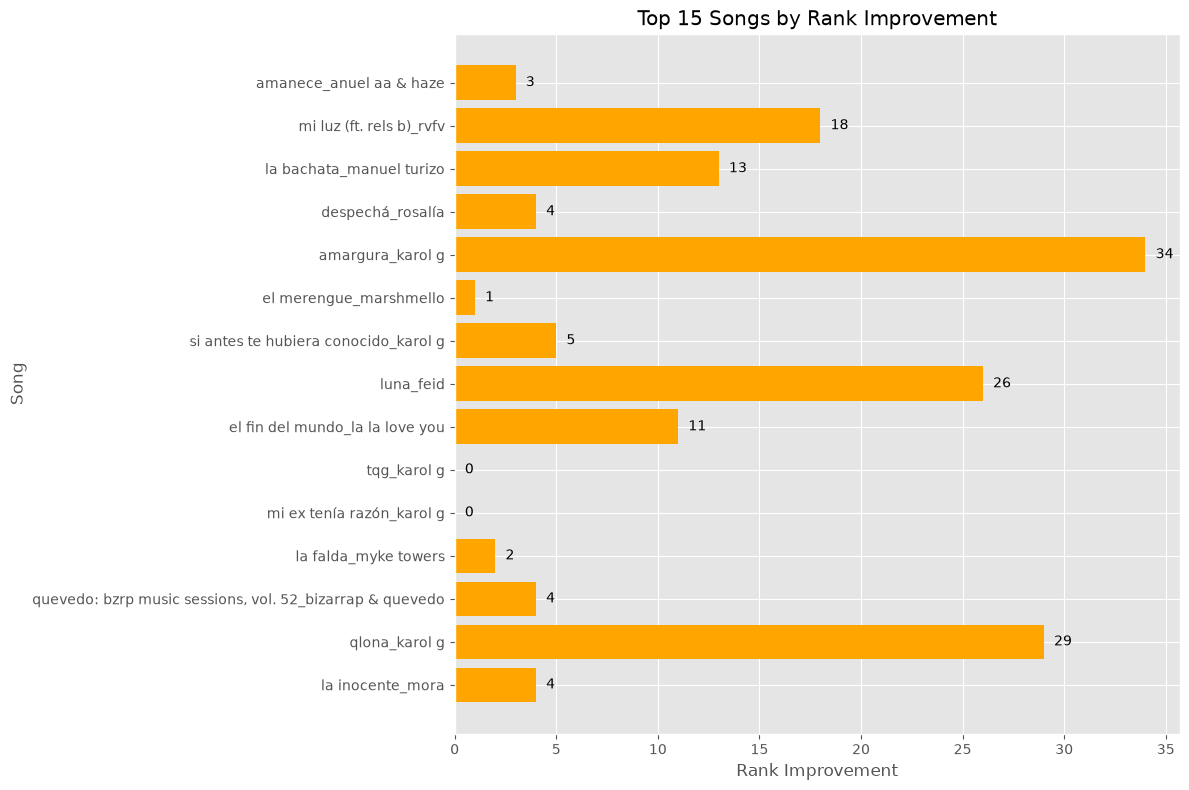

In [85]:
plt.figure(figsize=(12,8))

bars = plt.barh(
    top15["song_id"],
    top15["rank_improvement"],
    color="orange"
)

plt.title("Top 15 Songs by Rank Improvement")
plt.xlabel("Rank Improvement")
plt.ylabel("Song")

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center"
    )

plt.tight_layout()
plt.show()

Stability

In [21]:
top15 = lifecycle.sort_values(
    "stability_score",
    ascending=False
).head(15)

top15

,song_id,entry_date,exit_date,days_on_playlist,best_rank,worst_rank,avg_rank,initial_rank,rank_improvement,rank_range,rank_volatility,avg_daily_rank_change,peak_popularity,avg_popularity,popularity_gap,playlist_entries,days_to_peak,stability_score
26,amanece_anuel aa & haze,2024-05-25,2025-07-06,408,47,50,48.533333,50,3,3,1.060099,1.142857,85,81.466667,3.533333,15,29,198.048751
342,mi luz (ft. rels b)_rvfv,2024-10-23,2025-10-18,361,32,50,45.395349,50,18,18,3.610508,2.315789,81,77.261628,3.738372,172,353,78.299399
265,la bachata_manuel turizo,2024-05-18,2025-11-19,551,11,50,26.786642,24,13,39,8.490150,1.929368,88,85.636364,2.363636,539,228,58.060199
135,despechá_rosalía,2024-05-22,2025-01-02,226,39,50,47.019608,43,4,11,2.989918,1.960000,86,84.549020,1.450980,51,21,56.642772
29,amargura_karol g,2024-05-26,2025-10-31,524,16,50,32.764706,50,34,34,9.592188,1.953947,92,87.411765,4.588235,153,426,49.470423
167,el merengue_marshmello,2024-11-04,2025-11-18,380,19,50,36.476341,20,1,31,7.413013,2.417722,81,77.791798,3.208202,317,1,45.168122
483,si antes te hubiera conocido_karol g,2025-06-22,2025-11-27,159,1,22,2.439490,6,5,21,2.663470,0.365385,96,92.745223,3.254777,157,10,43.401477
312,luna_feid,2024-12-02,2025-11-27,361,2,50,11.599440,28,26,48,7.916297,1.056180,97,90.927171,6.072829,357,40,40.487661
163,el fin del mundo_la la love you,2025-06-03,2025-11-23,174,37,50,46.428571,48,11,13,3.321284,2.432990,70,68.010204,1.989796,98,83,40.265809
524,tqg_karol g,2024-05-18,2025-08-08,448,9,50,31.983333,9,0,41,10.925249,1.689076,96,93.066667,2.933333,120,0,37.567350


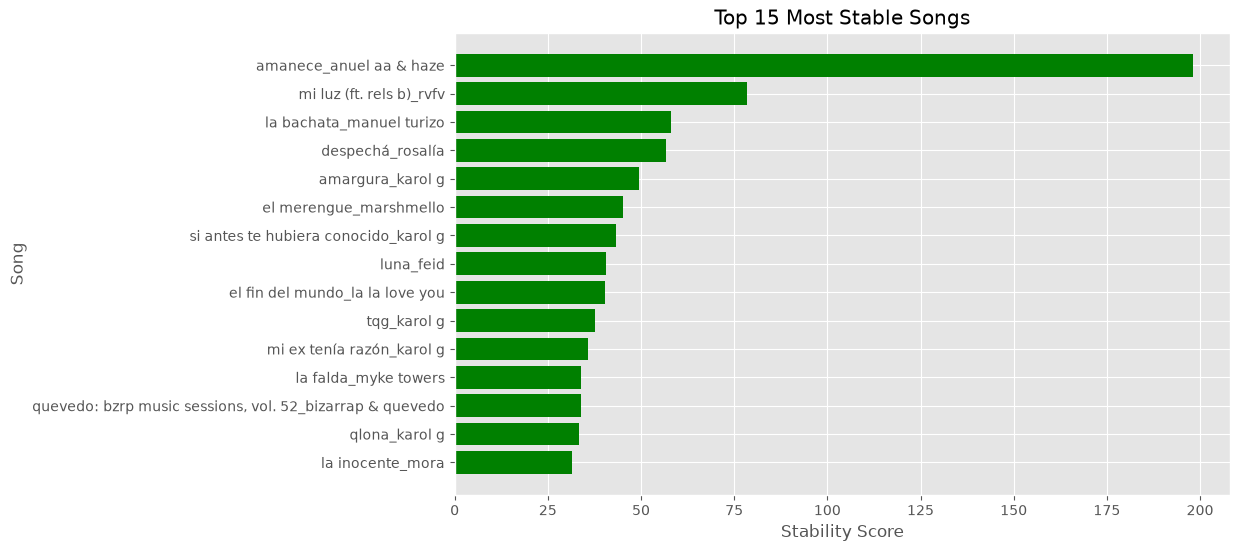

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    top15["song_id"],
    top15["stability_score"],
    color="green"
)

plt.title("Top 15 Most Stable Songs")
plt.xlabel("Stability Score")
plt.ylabel("Song")

plt.gca().invert_yaxis()   # Highest score at the top

plt.show()

### Observation

The songs with the highest stability scores remained on the playlist for a long period while experiencing relatively small ranking fluctuations. These tracks demonstrated consistent chart performance over time.

### Business Insight

Highly stable songs represent dependable long-term performers. Atlantic Records can use these tracks as benchmarks to identify the characteristics of sustainable hits and replicate those strategies in future releases.

Correlation

In [23]:
numeric = lifecycle.select_dtypes(include=np.number)

corr = numeric.corr()

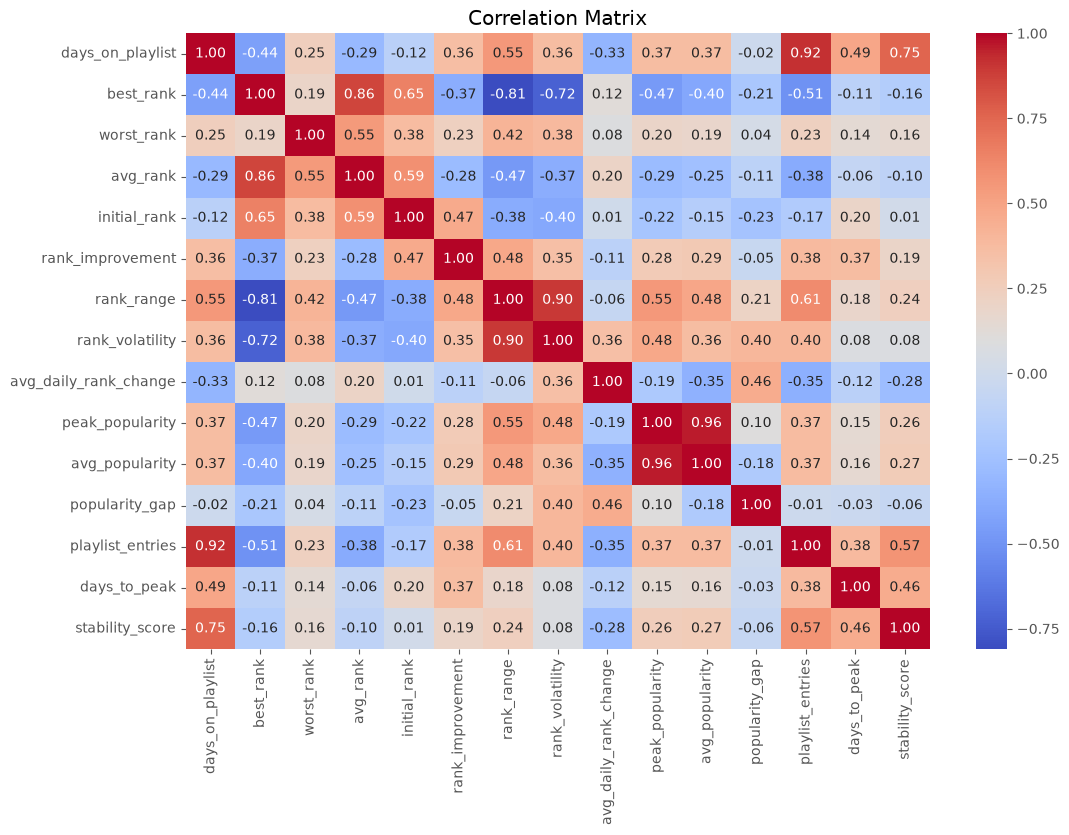

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
corr,
annot=True,
cmap="coolwarm",
fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Playlist Rotation

In [25]:
df

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,song_id,duration_min
0,2024-05-18,1,Supernova,Saiko,84,190909,single,1,False,https://i.scdn.co/image/ab67616d0000b273c3f5b9...,supernova_saiko,3.181817
1,2024-05-18,2,EL TONTO,Lola Indigo,83,187986,album,11,False,https://i.scdn.co/image/ab67616d0000b273daab36...,el tonto_lola indigo,3.133100
2,2024-05-18,3,Acróstico,Shakira,81,170785,single,1,False,https://i.scdn.co/image/ab67616d0000b273bd6bbd...,acróstico_shakira,2.846417
3,2024-05-18,4,BESO,ROSALÍA & Rauw Alejandro,96,194543,single,3,False,https://i.scdn.co/image/ab67616d0000b2734d6cf0...,beso_rosalía & rauw alejandro,3.242383
4,2024-05-18,5,El Merengue,Marshmello & Manuel Turizo,91,189668,single,1,False,https://i.scdn.co/image/ab67616d0000b273f40467...,el merengue_marshmello & manuel turizo,3.161133
...,...,...,...,...,...,...,...,...,...,...,...,...
27780,2025-11-27,46,Celine (with Kidd Keo),Ghost Killer Track & Kidd Keo,73,176017,single,1,False,https://i.scdn.co/image/ab67616d0000b273892224...,celine (with kidd keo)_ghost killer track & ki...,2.933617
27781,2025-11-27,47,Vacile,Yan Block,78,140239,single,1,True,https://i.scdn.co/image/ab67616d0000b273b7a46e...,vacile_yan block,2.337317
27782,2025-11-27,48,Rapido (with Cris Mj),Dei V,76,146000,album,16,True,https://i.scdn.co/image/ab67616d0000b2734258ad...,rapido (with cris mj)_dei v,2.433333
27783,2025-11-27,49,PELIGROSA,FloyyMenor,83,134930,album,7,True,https://i.scdn.co/image/ab67616d0000b273200e2b...,peligrosa_floyymenor,2.248833


In [26]:
daily = (
df.groupby("date")["song_id"]
.nunique()
)

In [27]:
daily.head()

date
2024-05-18    50
2024-05-19    50
2024-05-20    50
2024-05-21    50
2024-05-22    50
Name: song_id, dtype: int64

In [28]:
daily.describe()

count    555.000000
mean      50.001802
std        0.042448
min       50.000000
25%       50.000000
50%       50.000000
75%       50.000000
max       51.000000
Name: song_id, dtype: float64

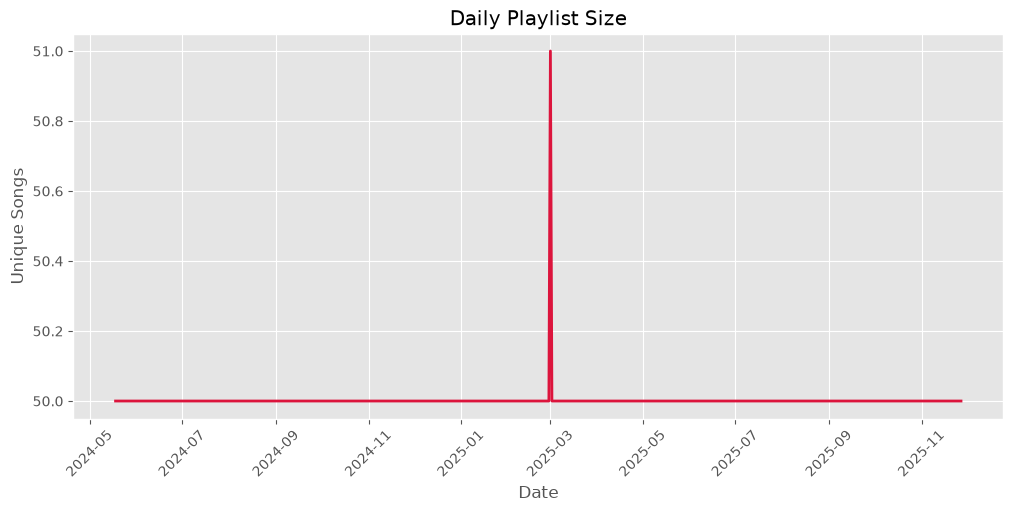

In [61]:
plt.figure(figsize=(12,5))

plt.plot(
    daily.index,
    daily.values,
    linewidth=2,
    color="crimson"
)

plt.title("Daily Playlist Size")
plt.xlabel("Date")
plt.ylabel("Unique Songs")

plt.xticks(rotation=45)

plt.show()

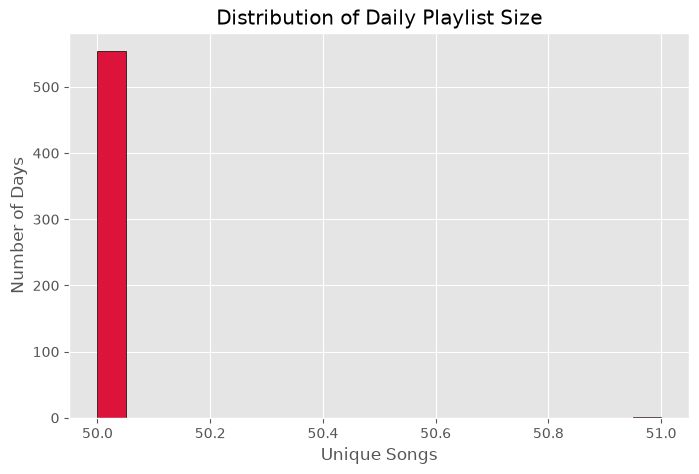

In [62]:
plt.figure(figsize=(8,5))

plt.hist(
    daily,
    bins=20,
    edgecolor="black",
    color="crimson"
)

plt.title("Distribution of Daily Playlist Size")
plt.xlabel("Unique Songs")
plt.ylabel("Number of Days")

plt.show()

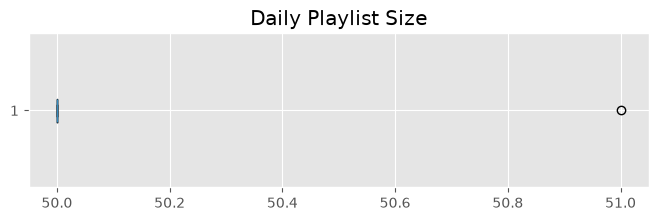

In [31]:
plt.figure(figsize=(8,2))

plt.boxplot(
    daily,
    orientation="horizontal"
)

plt.title("Daily Playlist Size")

plt.show()

### Observation

The playlist size remains relatively consistent across most dates, with only small fluctuations. This suggests that the Spotify Top 50 playlist maintains a fairly stable number of unique songs each day while gradually rotating tracks in and out.

### Business Insight

A stable playlist size indicates that playlist updates focus on replacing existing songs rather than expanding the playlist. This allows analysts to study song turnover, retention, and competition for limited playlist positions.

### Playlist Dynamics

#### Daily Entries

Daily entries represent the number of new songs that entered the Spotify Top 50 playlist compared to the previous day.

In [32]:
# Sort dates
dates = sorted(df["date"].unique())

daily_entries = []

for i in range(1, len(dates)):
    today = set(df[df["date"] == dates[i]]["song_id"])
    yesterday = set(df[df["date"] == dates[i-1]]["song_id"])

    entries = len(today - yesterday)

    daily_entries.append({
        "date": dates[i],
        "entries": entries
    })

daily_entries = pd.DataFrame(daily_entries)

daily_entries.head()

,date,entries
0,2024-05-19,0
1,2024-05-20,0
2,2024-05-21,4
3,2024-05-22,1
4,2024-05-23,0


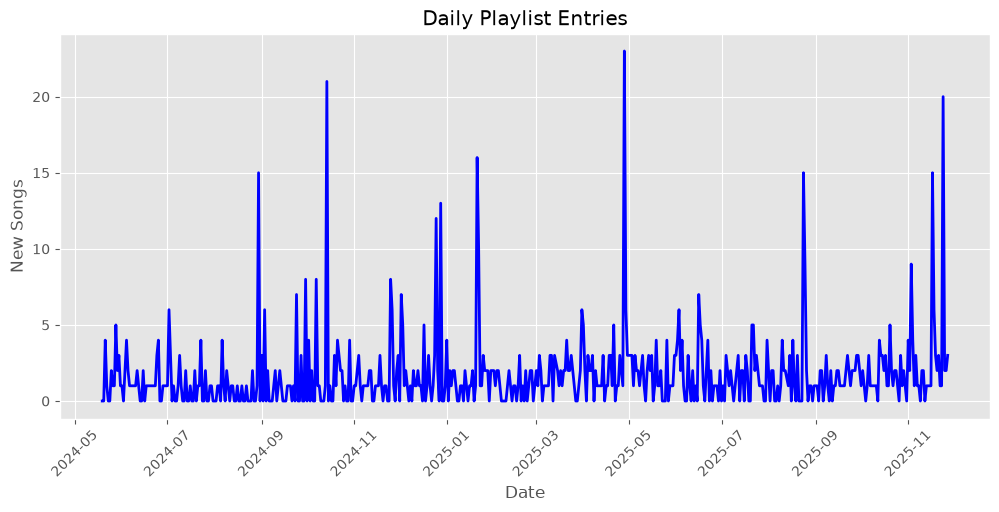

In [63]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_entries["date"],
    daily_entries["entries"],
    linewidth=2,
    color="blue"
)

plt.title("Daily Playlist Entries")
plt.xlabel("Date")
plt.ylabel("New Songs")

plt.xticks(rotation=45)

plt.show()

##### Observation

The number of new songs entering the playlist varies across dates, indicating that playlist updates are not uniform throughout the observation period.

##### Business Insight

Days with a high number of entries indicate aggressive playlist refreshes, providing opportunities for new releases to gain exposure.

#### Daily Exits

Daily exits represent songs that disappeared from the playlist compared to the previous day.

In [34]:
daily_exits = []

for i in range(1, len(dates)):
    today = set(df[df["date"] == dates[i]]["song_id"])
    yesterday = set(df[df["date"] == dates[i-1]]["song_id"])

    exits = len(yesterday - today)

    daily_exits.append({
        "date": dates[i],
        "exits": exits
    })

daily_exits = pd.DataFrame(daily_exits)

daily_exits.head()

,date,exits
0,2024-05-19,0
1,2024-05-20,0
2,2024-05-21,4
3,2024-05-22,1
4,2024-05-23,0


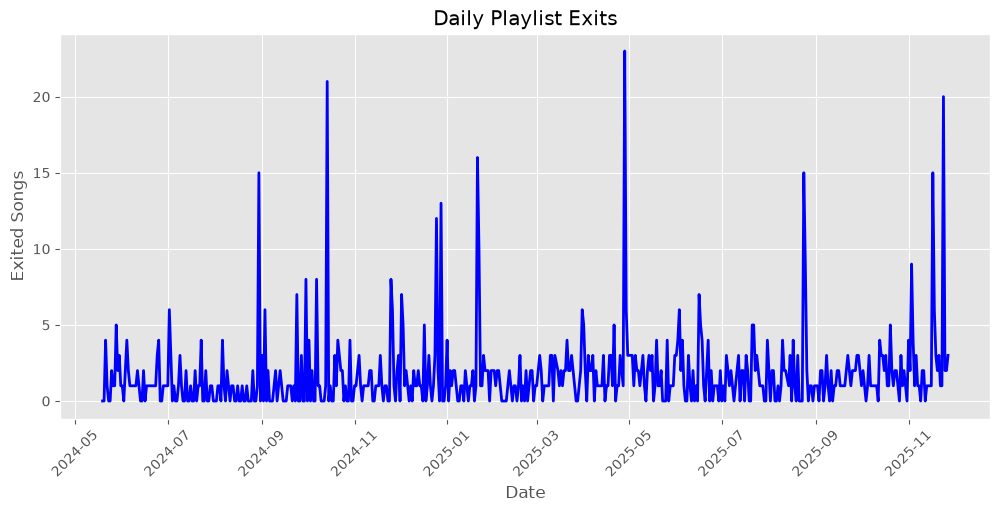

In [64]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_exits["date"],
    daily_exits["exits"],
    color="blue",
    linewidth=2
)

plt.title("Daily Playlist Exits")
plt.xlabel("Date")
plt.ylabel("Exited Songs")

plt.xticks(rotation=45)

plt.show()

##### Observation

Playlist exits generally mirror playlist entries, reflecting the replacement of older songs with newer tracks.

##### Business Insight

Monitoring playlist exits helps identify when songs lose momentum, allowing record labels to evaluate promotional effectiveness.

#### Daily Playlist Churn

Daily churn measures the total amount of playlist turnover by combining daily entries and exits.

In [36]:
daily_churn = daily_entries.merge(
    daily_exits,
    on="date"
)

daily_churn["churn"] = (
    daily_churn["entries"] +
    daily_churn["exits"]
)

daily_churn.head()

,date,entries,exits,churn
0,2024-05-19,0,0,0
1,2024-05-20,0,0,0
2,2024-05-21,4,4,8
3,2024-05-22,1,1,2
4,2024-05-23,0,0,0


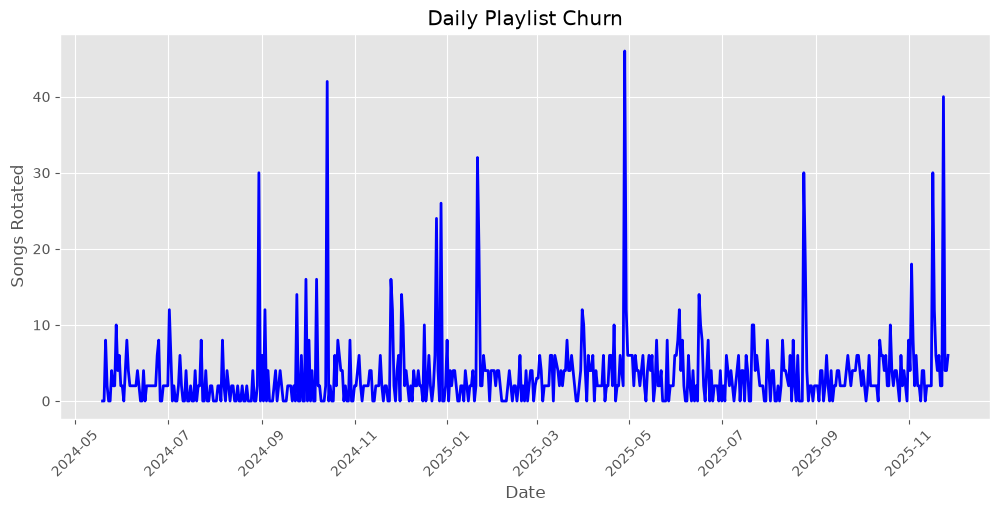

In [65]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_churn["date"],
    daily_churn["churn"],
    linewidth=2,
    color="blue"
)

plt.title("Daily Playlist Churn")
plt.xlabel("Date")
plt.ylabel("Songs Rotated")

plt.xticks(rotation=45)

plt.show()

##### Observation

Playlist churn fluctuates over time, with certain days experiencing significantly more rotation than others.

##### Business Insight

Higher playlist churn suggests periods of increased competition, where new songs replace existing tracks more rapidly.

#### Monthly Churn

In [39]:
daily_churn["date"] = pd.to_datetime(daily_churn["date"])

monthly_churn = (
    daily_churn
    .set_index("date")
    .resample("ME")
    .sum()
)

monthly_churn

,entries,exits,churn
date,,,
2024-05-31,20,20,40
2024-06-30,36,36,72
2024-07-31,31,31,62
2024-08-31,33,33,66
2024-09-30,40,40,80
2024-10-31,59,59,118
2024-11-30,45,45,90
2024-12-31,67,67,134
2025-01-31,63,63,126


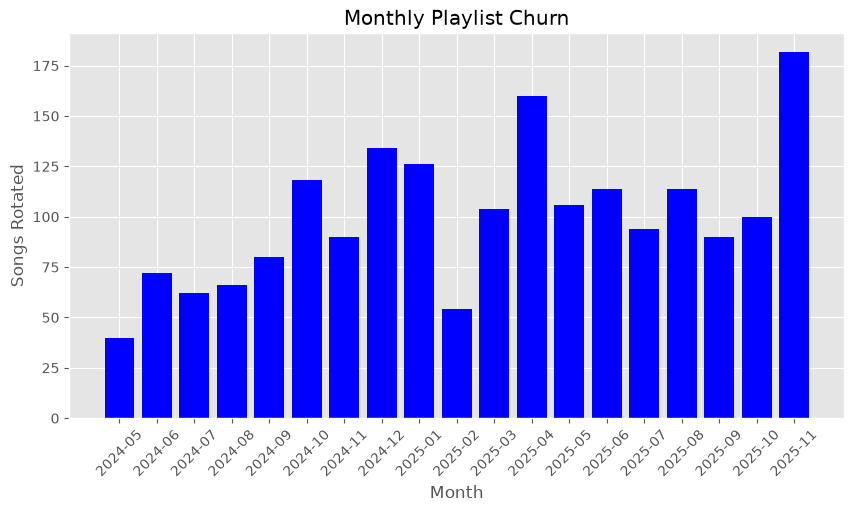

In [66]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_churn.index.strftime("%Y-%m"),
    monthly_churn["churn"],
    color="blue"
)

plt.title("Monthly Playlist Churn")
plt.xlabel("Month")
plt.ylabel("Songs Rotated")

plt.xticks(rotation=45)

plt.show()

##### Observation

Monthly playlist churn highlights periods where playlist updates were more frequent, indicating changes in music trends and listener preferences.

##### Business Insight

Understanding monthly churn helps Atlantic Records identify seasonal playlist behavior and optimize release schedules to maximize playlist exposure.

### Artist Analysis

In [49]:
top_artists = (
    df["artist"]
    .value_counts()
    .head(15)
)

top_artists

artist
Myke Towers                                1231
Quevedo                                    1106
KAROL G                                     923
Bad Bunny                                   821
Mora                                        816
Dei V                                       654
Saiko                                       652
Feid                                        642
SAIKO                                       583
Rauw Alejandro                              569
Manuel Turizo                               543
Lola Indigo                                 464
Eladio Carrion                              394
Sebastian Yatra & Manuel Turizo & Beéle     386
DELLAFUENTE & Morad                         330
Name: count, dtype: int64

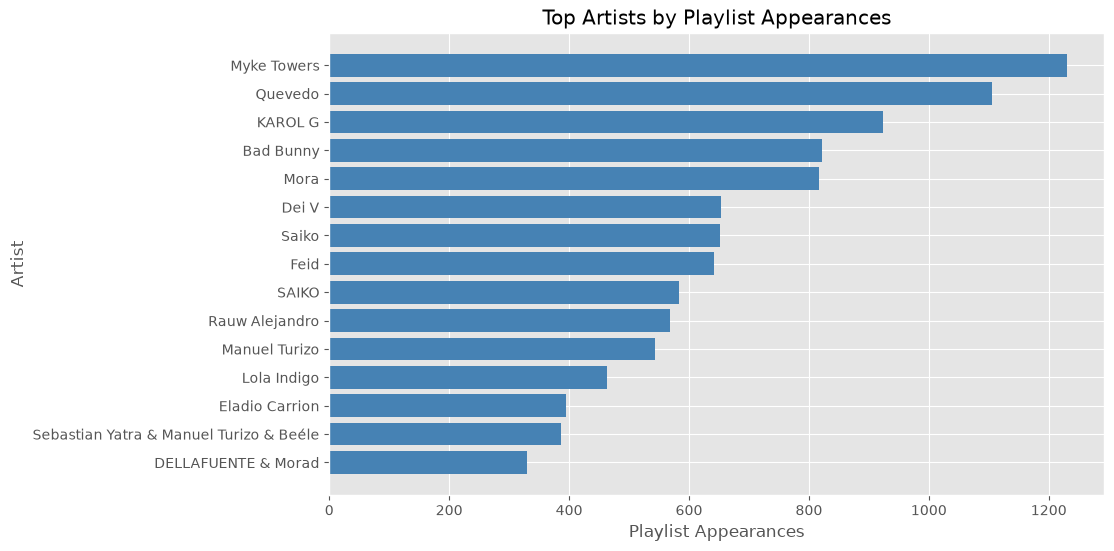

In [50]:
plt.figure(figsize=(10,6))

plt.barh(
    top_artists.index,
    top_artists.values,
    color="steelblue"
)

plt.title("Top Artists by Playlist Appearances")
plt.xlabel("Playlist Appearances")
plt.ylabel("Artist")

plt.gca().invert_yaxis()

plt.show()

In [51]:
artist_songs = (
    df.groupby("artist")["song_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(15)
)

artist_songs

artist
Myke Towers       24
Quevedo           24
Bad Bunny         22
Rauw Alejandro    19
Mora              19
Eladio Carrion    19
Feid              18
SAIKO             16
Duki              14
Rels B            10
Saiko              9
KAROL G            9
Cruz Cafuné        8
Aitana             6
Dei V              6
Name: song_id, dtype: int64

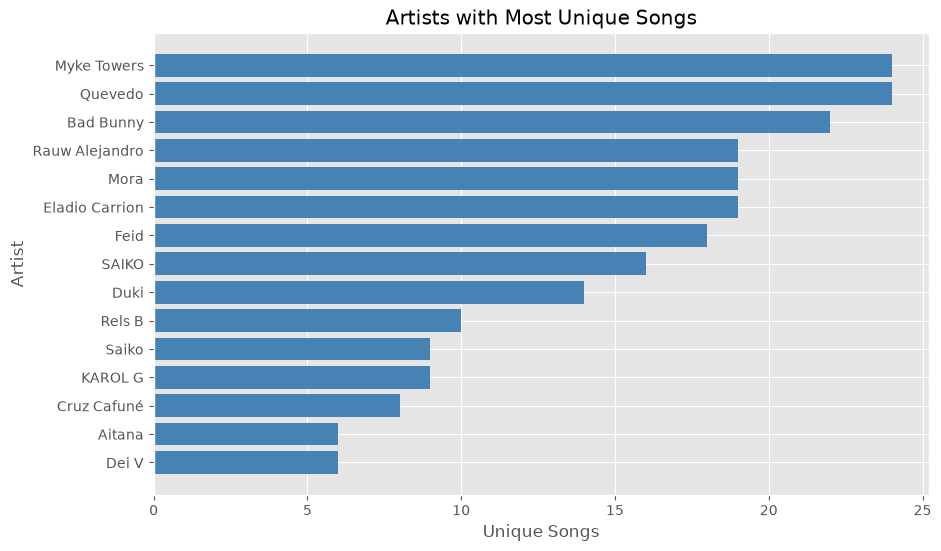

In [67]:
plt.figure(figsize=(10,6))

plt.barh(
    artist_songs.index,
    artist_songs.values,
    color="steelblue"
)

plt.title("Artists with Most Unique Songs")
plt.xlabel("Unique Songs")
plt.ylabel("Artist")

plt.gca().invert_yaxis()

plt.show()

In [53]:
artist_popularity = (
    df.groupby("artist")["popularity"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

artist_popularity

artist
Grupo Frontera & Bad Bunny    99.962963
Lady Gaga & Bruno Mars        99.770833
Mariah Carey                  99.000000
Yng Lvcas & Peso Pluma        98.365385
Brenda Lee                    98.000000
Artemas                       97.857143
FloyyMenor & Cris Mj          95.208589
Dean Martin                   95.000000
Feid & Young Miko             94.688525
Bizarrap & Peso Pluma         94.448276
Sia                           94.000000
Bobby Helms                   94.000000
ROSALÍA & Rauw Alejandro      93.901408
Bizarrap & Shakira            93.672131
iñigo quintero                93.470588
Name: popularity, dtype: float64

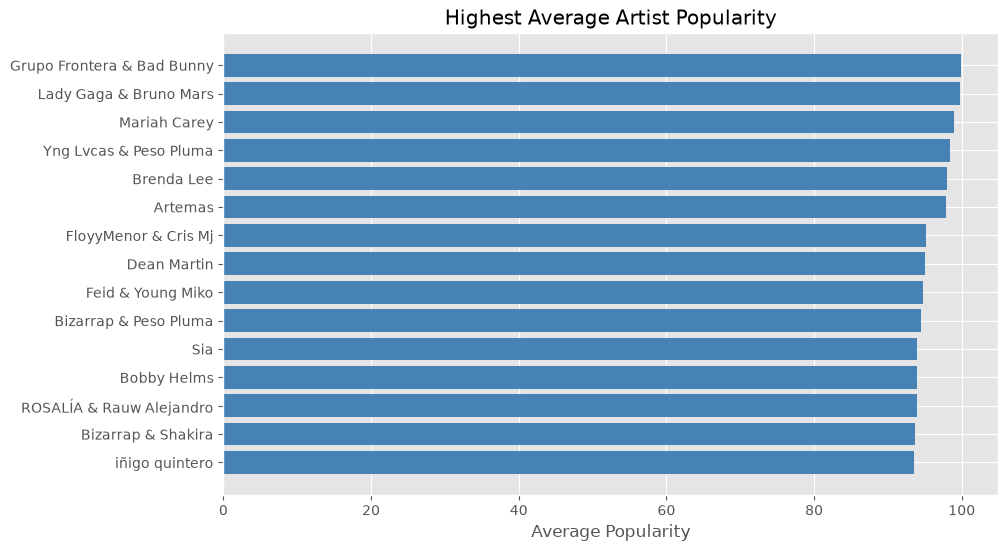

In [68]:
plt.figure(figsize=(10,6))

plt.barh(
    artist_popularity.index,
    artist_popularity.values,
    color="steelblue"
)

plt.title("Highest Average Artist Popularity")
plt.xlabel("Average Popularity")

plt.gca().invert_yaxis()

plt.show()

In [55]:
artist_life = (
    df[["song_id", "artist"]]
    .drop_duplicates()
    .merge(
        lifecycle[["song_id", "days_on_playlist"]],
        on="song_id"
    )
)

artist_longevity = (
    artist_life.groupby("artist")["days_on_playlist"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

artist_longevity

artist
Sebastian Yatra & Manuel Turizo & Beéle    517.0
Anuel AA & Haze                            408.0
Marshmello                                 380.0
SAIKO & Feid & Quevedo                     314.0
Saiko & Feid & Quevedo                     314.0
Sky Rompiendo & Feid & Myke Towers         279.0
Manuel Turizo                              277.5
Morad & Beny Jr & Rvfv                     259.0
LIT killah                                 258.0
Dei V & Bryant Myers                       251.0
Lola Indigo & Manuel Turizo                249.0
Omar Montes & Saiko & Tunvao               245.0
Vicco                                      237.0
Chanel & Abraham Mateo                     232.0
Bizarrap & Quevedo                         231.0
Name: days_on_playlist, dtype: float64

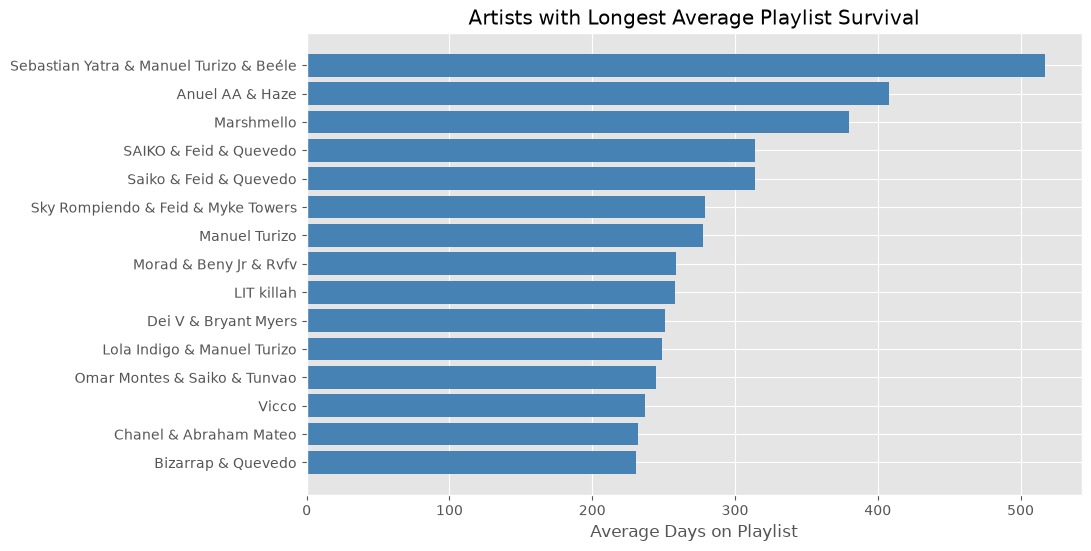

In [69]:
plt.figure(figsize=(10,6))

plt.barh(
    artist_longevity.index,
    artist_longevity.values,
    color="steelblue"
)

plt.title("Artists with Longest Average Playlist Survival")
plt.xlabel("Average Days on Playlist")

plt.gca().invert_yaxis()

plt.show()

How well do songs perform at their peak?

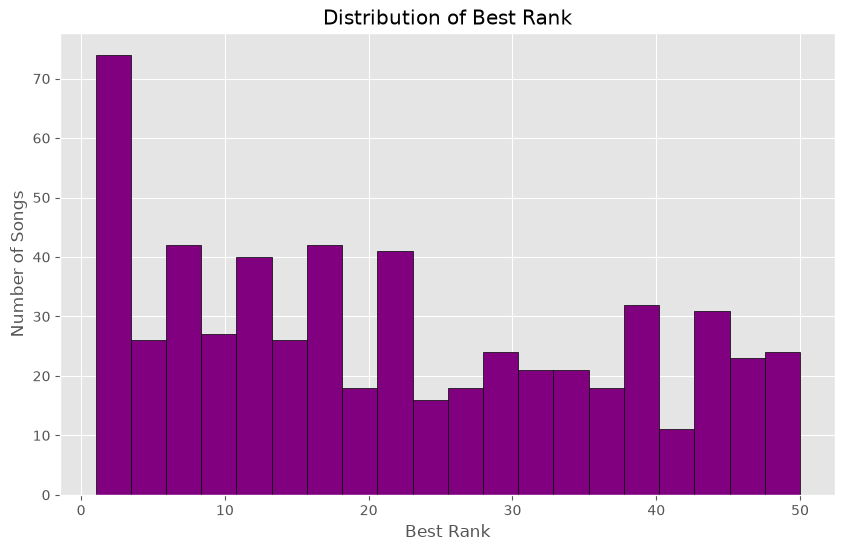

In [70]:
plt.figure(figsize=(10,6))

plt.hist(
    lifecycle["best_rank"],
    bins=20,
    edgecolor="black",
    color="purple"
)

plt.title("Distribution of Best Rank")
plt.xlabel("Best Rank")
plt.ylabel("Number of Songs")

plt.show()

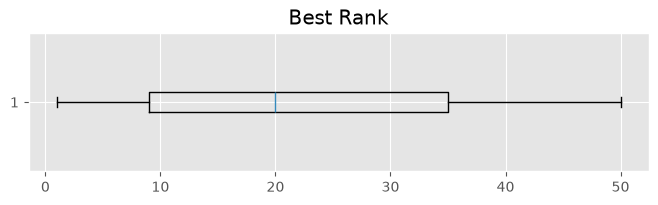

In [42]:
plt.figure(figsize=(8,1.8))

plt.boxplot(
    lifecycle["best_rank"],
    orientation="horizontal"
)

plt.title("Best Rank")

plt.show()

### Observation

The distribution shows how many songs reached high chart positions.

Lower rank values indicate better performance.

The boxplot highlights whether a few songs achieved exceptionally strong rankings compared to the rest.

### Business Insight

If only a small percentage of songs reach Top 10, the label should investigate the factors behind these successful releases and replicate those strategies.

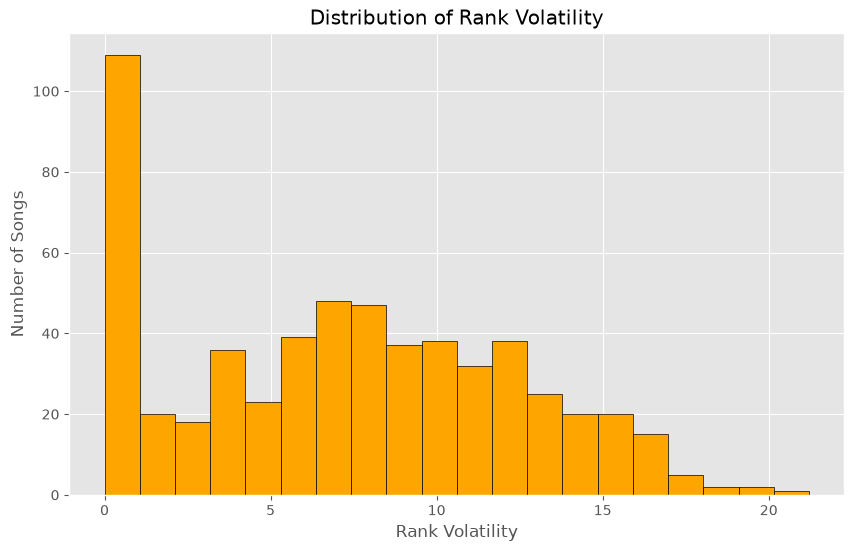

In [71]:
plt.figure(figsize=(10,6))

plt.hist(
    lifecycle["rank_volatility"],
    bins=20,
    edgecolor="black",
    color="orange"
)

plt.title("Distribution of Rank Volatility")
plt.xlabel("Rank Volatility")
plt.ylabel("Number of Songs")

plt.show()

Business insight

* Lower volatility → more stable hits.
* Higher volatility → songs rise and fall quickly.

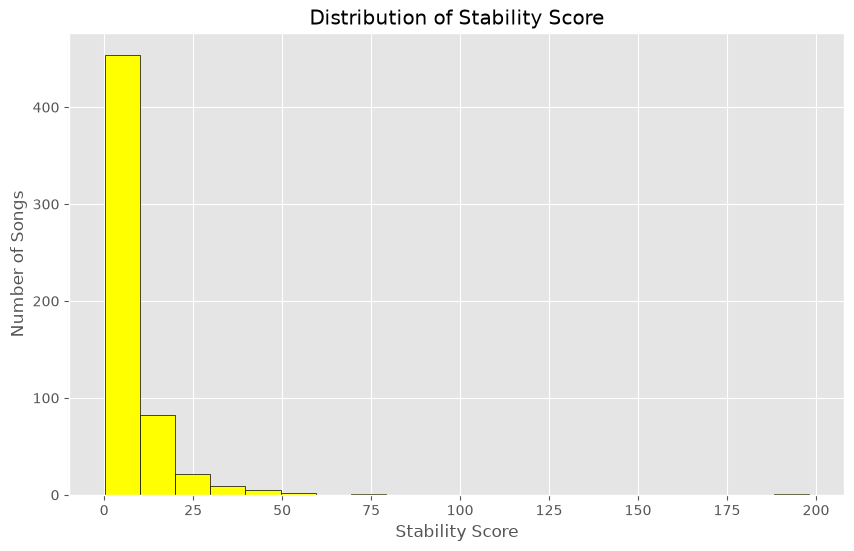

In [72]:
plt.figure(figsize=(10,6))

plt.hist(
    lifecycle["stability_score"],
    bins=20,
    edgecolor="black",
    color="yellow"
)

plt.title("Distribution of Stability Score")
plt.xlabel("Stability Score")
plt.ylabel("Number of Songs")

plt.show()

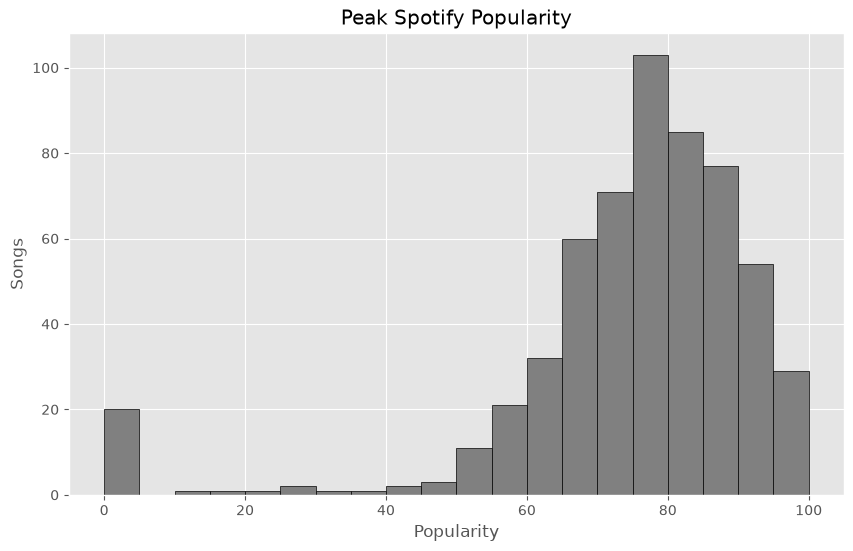

In [73]:
plt.figure(figsize=(10,6))

plt.hist(
    lifecycle["peak_popularity"],
    bins=20,
    edgecolor="black",
    color="grey"
)

plt.title("Peak Spotify Popularity")
plt.xlabel("Popularity")
plt.ylabel("Songs")

plt.show()

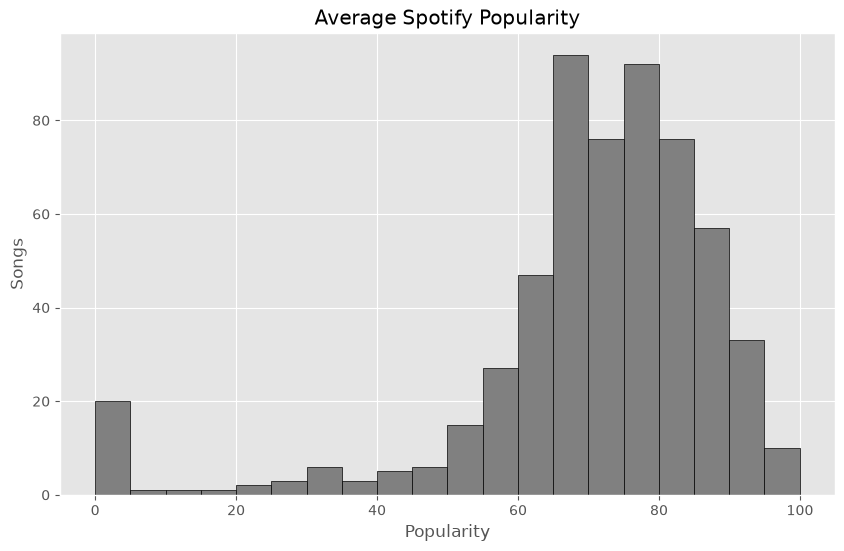

In [74]:
plt.figure(figsize=(10,6))

plt.hist(
    lifecycle["avg_popularity"],
    bins=20,
    edgecolor="black",
    color="grey"
)

plt.title("Average Spotify Popularity")
plt.xlabel("Popularity")
plt.ylabel("Songs")

plt.show()

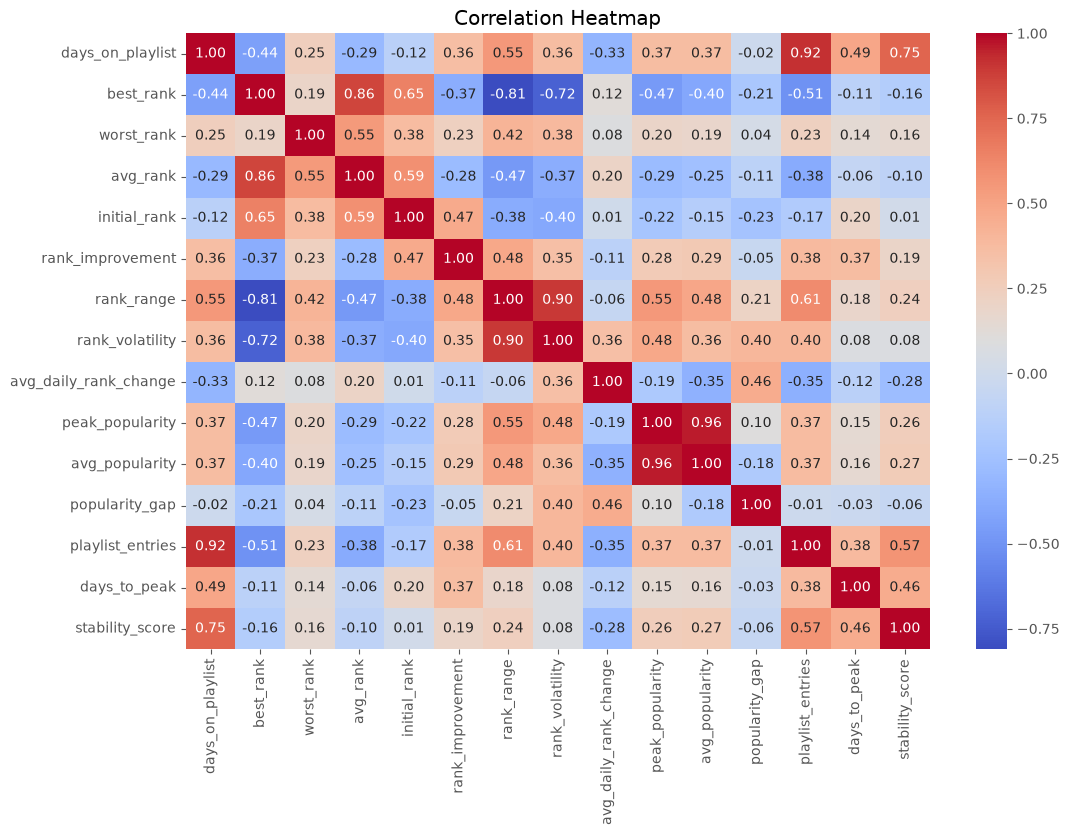

In [47]:
plt.figure(figsize=(12,8))

corr = lifecycle.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

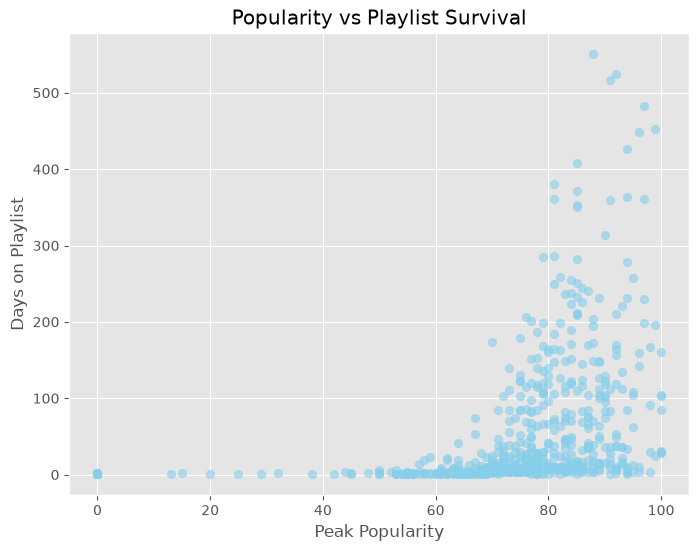

In [77]:
plt.figure(figsize=(8,6))

plt.scatter(
    lifecycle["peak_popularity"],
    lifecycle["days_on_playlist"],
    alpha=0.6,
    color="skyblue"
)

plt.xlabel("Peak Popularity")
plt.ylabel("Days on Playlist")
plt.title("Popularity vs Playlist Survival")

plt.show()

# Business Insights

## Playlist Longevity
- Most songs survive less than 60 days.
- Only a small number remain on the playlist for several months.

## Rank Performance
- A few songs consistently reach Top 10 positions.
- High rank volatility indicates unstable audience interest.

## Popularity
- Songs with higher Spotify popularity generally survive longer.
- Popularity alone does not guarantee long playlist life.

## Artists
- Certain artists appear repeatedly, showing strong audience preference.

## Albums
- Album tracks generally have shorter survival compared to singles.

## Playlist Rotation
- Daily playlist size remains relatively stable.
- Entries and exits fluctuate throughout the year.
- Monthly churn highlights periods of aggressive playlist refresh.

## Recommendation
Atlantic Records should:
- Promote artists with consistent long-term performance.
- Identify characteristics of high-survival songs.
- Use stability metrics when selecting future playlist additions.